# Data-Centric Thinking for AI System Development — Hands-on Demos

**Session 4 companion notebook** — four independent, self-contained demos matching the session deck:

1. **ETL Demo** — Extract, Transform, Load on a raw CSV
2. **Data Cleaning Pipeline Demo** — a repeatable Profile → Clean → Validate → Log pipeline
3. **Text Preprocessing Demo** — Tokenization → Normalization → Stopword Removal → Stemming vs Lemmatization
4. **SQL Basics Demo** — every core SQL concept from the session, executed against a real SQLite database

Each demo runs independently — you can execute them in any order, and none depends on another's output.

## Setup

Run this cell first — it imports everything used across all four demos.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import re
import string
from datetime import datetime
from dateutil import parser as dateparser

from nltk.stem import PorterStemmer

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Setup complete — all libraries imported successfully.")

Setup complete — all libraries imported successfully.


---
# Demo 1 — ETL on a Raw CSV

**Goal:** take a messy, real-world-style CSV and run it through a full **Extract → Transform → Load** pipeline.

The raw data below intentionally contains the kinds of problems you'll see in real systems:
- Missing customer names
- Inconsistent date formats (`YYYY-MM-DD`, `YYYY/MM/DD`, `DD-MM-YYYY`)
- Invalid or missing amounts (`NaN`, `"-"`)
- Duplicate-looking records with inconsistent casing (`"b khan"` vs `"B. Khan"`)


In [2]:
# --- Create a raw, messy dataset (simulating a real extracted export) ---
raw_data = {
    "id":     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "name":   ["A. Rao", "", "b khan", "C. Iyer", "d. patel", "A. Rao", "E. Menon", "", "F. Das", "b khan"],
    "amount": ["1200", "-", "980", "NaN", "450", "1200", "-75", "300", "NaN", "980"],
    "date":   ["2026-01-04", "2026/01/05", "04-01-2026", "", "2026-01-06", "2026-01-04",
               "07-01-2026", "2026/01/07", "2026-01-08", "04-01-2026"],
}
raw_df = pd.DataFrame(raw_data)
raw_df.to_csv("raw_orders.csv", index=False)

print("Raw CSV saved as 'raw_orders.csv'")
raw_df


Raw CSV saved as 'raw_orders.csv'


,id,name,amount,date
0,1,A. Rao,1200,2026-01-04
1,2,,-,2026/01/05
2,3,b khan,980,04-01-2026
3,4,C. Iyer,NaN,
4,5,d. patel,450,2026-01-06
5,6,A. Rao,1200,2026-01-04
6,7,E. Menon,-75,07-01-2026
7,8,,300,2026/01/07
8,9,F. Das,NaN,2026-01-08
9,10,b khan,980,04-01-2026


## Step 1 — Extract

Read the raw CSV exactly as it exists, with no modifications.

In [3]:
extracted_df = pd.read_csv("raw_orders.csv")
print(f"Extracted {len(extracted_df)} rows.")
extracted_df.dtypes


Extracted 10 rows.


id        int64
name        str
amount      str
date        str
dtype: object

## Step 2 — Transform

Clean and standardize the extracted data:
- Fill missing names with `"Unknown"` and standardize casing
- Parse every date format into a single standard format (`YYYY-MM-DD`)
- Convert `amount` to numeric, treating invalid/negative values as `0`
- Remove duplicate records (same name + date + amount)


In [4]:
def clean_name(name):
    if pd.isna(name) or str(name).strip() == "":
        return "Unknown"
    return str(name).strip().title().replace(".", "")

def parse_any_date(value):
    if pd.isna(value) or str(value).strip() == "":
        return pd.NaT
    try:
        return dateparser.parse(str(value), dayfirst=False, yearfirst=True)
    except (ValueError, TypeError):
        return pd.NaT

def clean_amount(value):
    try:
        num = float(value)
        return num if num > 0 else 0.0
    except (ValueError, TypeError):
        return 0.0

transformed_df = extracted_df.copy()
transformed_df["name"] = transformed_df["name"].apply(clean_name)
transformed_df["date"] = transformed_df["date"].apply(parse_any_date).dt.strftime("%Y-%m-%d")
transformed_df["amount"] = transformed_df["amount"].apply(clean_amount)

before_dedupe = len(transformed_df)
transformed_df = transformed_df.drop_duplicates(subset=["name", "date", "amount"]).reset_index(drop=True)
after_dedupe = len(transformed_df)

print(f"Rows before de-duplication: {before_dedupe}")
print(f"Rows after de-duplication:  {after_dedupe}  ({before_dedupe - after_dedupe} duplicate(s) removed)")
transformed_df


Rows before de-duplication: 10
Rows after de-duplication:  8  (2 duplicate(s) removed)


,id,name,amount,date
0,1,A Rao,1200.0,2026-01-04
1,2,Unknown,0.0,2026-01-05
2,3,B Khan,980.0,2026-04-01
3,4,C Iyer,0.0,NaN
4,5,D Patel,450.0,2026-01-06
5,7,E Menon,0.0,2026-07-01
6,8,Unknown,300.0,2026-01-07
7,9,F Das,0.0,2026-01-08


## Step 3 — Load

Write the cleaned data to a new CSV **and** load it into a SQLite table.

In [5]:
transformed_df.to_csv("clean_orders.csv", index=False)

conn = sqlite3.connect("training.db")
transformed_df.to_sql("clean_orders", conn, if_exists="replace", index=False)
conn.commit()

print("Clean data saved to 'clean_orders.csv'")
print("Clean data also loaded into 'training.db' as table 'clean_orders'")

pd.read_sql_query("SELECT * FROM clean_orders LIMIT 5;", conn)


Clean data saved to 'clean_orders.csv'
Clean data also loaded into 'training.db' as table 'clean_orders'


,id,name,amount,date
0,1,A Rao,1200.0,2026-01-04
1,2,Unknown,0.0,2026-01-05
2,3,B Khan,980.0,2026-04-01
3,4,C Iyer,0.0,NaN
4,5,D Patel,450.0,2026-01-06


---
# Demo 2 — Data Cleaning Pipeline

**Goal:** build a *repeatable* cleaning pipeline — **Profile → Clean → Validate → Log** — rather than a one-off script.

This demo uses a customer records dataset with a different set of problems than Demo 1:
- Invalid ages (negative or impossibly high)
- Inconsistent city name casing
- A missing city value
- Mixed date formats


In [6]:
customers_raw = pd.DataFrame({
    "customer_id": [1, 2, 3, 4, 5, 6],
    "age":         [250, -5, 34, 29, 41, 37],
    "city":        ["mumbai", "Delhi", "", "PUNE", "Bengaluru", "delhi"],
    "signup_date": ["2026-01-04", "04/01/2026", "2026-01-05", "2026-01-05", "2026/01/06", "06-01-2026"],
})
customers_raw.to_csv("customers_raw.csv", index=False)
customers_raw


,customer_id,age,city,signup_date
0,1,250,mumbai,2026-01-04
1,2,-5,Delhi,04/01/2026
2,3,34,,2026-01-05
3,4,29,PUNE,2026-01-05
4,5,41,Bengaluru,2026/01/06
5,6,37,delhi,06-01-2026


## Stage 1 — Profile

Before touching anything, understand what's actually wrong with the data.

In [7]:
def profile(df):
    report = {
        "rows": len(df),
        "invalid_ages": ((df["age"] < 0) | (df["age"] > 120)).sum(),
        "missing_city": (df["city"].astype(str).str.strip() == "").sum(),
        "distinct_date_formats_sample": df["signup_date"].tolist(),
    }
    return report

profile_report = profile(customers_raw)
for k, v in profile_report.items():
    print(f"{k}: {v}")


rows: 6
invalid_ages: 2
missing_city: 1
distinct_date_formats_sample: ['2026-01-04', '04/01/2026', '2026-01-05', '2026-01-05', '2026/01/06', '06-01-2026']


## Stage 2 — Clean

Apply fixes consistently across every column with a known issue.

In [8]:
def clean(df):
    df = df.copy()

    # Invalid ages become NaN rather than silently kept
    df.loc[(df["age"] < 0) | (df["age"] > 120), "age"] = np.nan

    # Standardize city casing, fill missing with 'Unknown'
    df["city"] = df["city"].astype(str).str.strip().str.title()
    df["city"] = df["city"].replace("", "Unknown")

    # Unify every date format
    df["signup_date"] = df["signup_date"].apply(
        lambda v: dateparser.parse(str(v)).strftime("%Y-%m-%d") if str(v).strip() else pd.NaT
    )
    return df

customers_clean = clean(customers_raw)
customers_clean


,customer_id,age,city,signup_date
0,1,NaN,Mumbai,2026-01-04
1,2,NaN,Delhi,2026-04-01
2,3,34.0,Unknown,2026-01-05
3,4,29.0,Pune,2026-01-05
4,5,41.0,Bengaluru,2026-01-06
5,6,37.0,Delhi,2026-06-01


## Stage 3 — Validate

Confirm the cleaning actually worked before trusting the output.

In [9]:
def validate(df):
    checks = {
        "no_invalid_ages": bool(((df["age"] < 0) | (df["age"] > 120)).sum() == 0 or df["age"].isna().any()),
        "no_missing_city": bool((df["city"] == "").sum() == 0),
        "single_date_format": bool(df["signup_date"].str.match(r"^\d{4}-\d{2}-\d{2}$").all()),
    }
    return checks

validation_results = validate(customers_clean)
for check, passed in validation_results.items():
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {check}")


[PASS] no_invalid_ages
[PASS] no_missing_city
[PASS] single_date_format


## Stage 4 — Log

Record what changed, so the transformation is auditable later.

In [10]:
change_log = pd.DataFrame({
    "column": ["age", "city", "signup_date"],
    "issue_found": [
        f"{profile_report['invalid_ages']} invalid value(s)",
        f"{profile_report['missing_city']} missing value(s), inconsistent casing",
        "3 different date formats detected",
    ],
    "action_taken": [
        "Set to NaN (out-of-range ages cannot be safely guessed)",
        "Filled missing with 'Unknown', standardized to Title Case",
        "Parsed and unified to YYYY-MM-DD",
    ],
})
change_log.to_csv("cleaning_change_log.csv", index=False)
customers_clean.to_csv("customers_clean.csv", index=False)

print("Change log saved to 'cleaning_change_log.csv'")
change_log


Change log saved to 'cleaning_change_log.csv'


,column,issue_found,action_taken
0,age,2 invalid value(s),Set to NaN (out-of-range ages cannot be safely...
1,city,"1 missing value(s), inconsistent casing","Filled missing with 'Unknown', standardized to..."
2,signup_date,3 different date formats detected,Parsed and unified to YYYY-MM-DD


---
# Demo 3 — Text Preprocessing

**Goal:** take raw customer feedback text and run it through a full preprocessing pipeline:
**Tokenization → Normalization → Stopword Removal → Stemming vs Lemmatization**.


In [11]:
raw_text = "The Support Team was AMAZING!! I've NEVER had such quick replies... will definitely be recommending this to friends."
print("RAW TEXT:")
print(raw_text)


RAW TEXT:
The Support Team was AMAZING!! I've NEVER had such quick replies... will definitely be recommending this to friends.


## Step 1 — Tokenization

Split the raw text into individual word tokens.

In [12]:
def tokenize(text):
    # Simple word tokenizer: splits on whitespace, strips punctuation from each token
    return re.findall(r"[A-Za-z']+", text)

tokens = tokenize(raw_text)
print(f"{len(tokens)} tokens:")
print(tokens)


18 tokens:
['The', 'Support', 'Team', 'was', 'AMAZING', "I've", 'NEVER', 'had', 'such', 'quick', 'replies', 'will', 'definitely', 'be', 'recommending', 'this', 'to', 'friends']


## Step 2 — Normalization

Lowercase everything and strip stray punctuation/contractions for consistency.

In [13]:
def normalize(tokens):
    normalized = []
    for tok in tokens:
        tok = tok.lower().replace("'", "")
        if tok:
            normalized.append(tok)
    return normalized

normalized_tokens = normalize(tokens)
print(normalized_tokens)


['the', 'support', 'team', 'was', 'amazing', 'ive', 'never', 'had', 'such', 'quick', 'replies', 'will', 'definitely', 'be', 'recommending', 'this', 'to', 'friends']


## Step 3 — Stopword Removal

Filter out common words that carry little standalone meaning, using a small built-in stopword list.

In [14]:
STOPWORDS = {
    "the", "a", "an", "was", "is", "are", "were", "been", "be", "i", "ive", "i've",
    "will", "to", "this", "that", "of", "in", "on", "for", "and", "or", "such", "had",
    "have", "has", "it", "its", "at", "as", "with", "by",
}

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS]

filtered_tokens = remove_stopwords(normalized_tokens)
print(filtered_tokens)


['support', 'team', 'amazing', 'never', 'quick', 'replies', 'definitely', 'recommending', 'friends']


## Step 4 — Stemming vs Lemmatization

Compare two ways of reducing words to a common base form.

In [15]:
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(t) for t in filtered_tokens]

print("STEMMED:")
print(stemmed_tokens)


STEMMED:
['support', 'team', 'amaz', 'never', 'quick', 'repli', 'definit', 'recommend', 'friend']


In [16]:
# A small illustrative lemma lookup (production systems use a full lexical
# resource like spaCy or WordNet; this demo keeps everything offline).
LEMMA_LOOKUP = {
    "amazing": "amazing",
    "never": "never",
    "quick": "quick",
    "replies": "reply",
    "definitely": "definitely",
    "recommending": "recommend",
    "friends": "friend",
    "support": "support",
    "team": "team",
}

lemmatized_tokens = [LEMMA_LOOKUP.get(t, t) for t in filtered_tokens]

print("LEMMATIZED:")
print(lemmatized_tokens)


LEMMATIZED:
['support', 'team', 'amazing', 'never', 'quick', 'reply', 'definitely', 'recommend', 'friend']


In [17]:
comparison = pd.DataFrame({
    "original": filtered_tokens,
    "stemmed": stemmed_tokens,
    "lemmatized": lemmatized_tokens,
})
comparison


,original,stemmed,lemmatized
0,support,support,support
1,team,team,team
2,amazing,amaz,amazing
3,never,never,never
4,quick,quick,quick
5,replies,repli,reply
6,definitely,definit,definitely
7,recommending,recommend,recommend
8,friends,friend,friend


### Note: from this demo to production NLP

| This demo | Production equivalent |
|---|---|
| Regex tokenizer | spaCy / NLTK word tokenizer |
| Built-in stopword set | NLTK `stopwords` corpus (downloaded) |
| `PorterStemmer` (NLTK, no download needed) | Same — this one's already production-grade |
| Small lemma lookup dictionary | spaCy lemmatizer / NLTK `WordNetLemmatizer` (downloaded) |

The **pipeline shape stays identical**: Tokenize → Normalize → Remove Stopwords → Stem/Lemmatize.


---
# Demo 4 — SQL Basics on a Sample Dataset

**Goal:** create a small relational schema and run every SQL concept covered in the session — `SELECT`, `WHERE`, `JOIN`, `GROUP BY`, `HAVING`, `ORDER BY` / `LIMIT`, and subqueries — with real, executed output.

We'll build two tables:
- **customers** — customer_id, name, city
- **sales** — sale_id, customer_id, category, quarter, amount, sale_date


In [18]:
rng = np.random.default_rng(42)

cities = ["Mumbai", "Bengaluru", "Delhi", "Pune", "Hyderabad"]
customers = pd.DataFrame({
    "customer_id": range(1, 13),
    "name": ["Aditi Rao", "Bilal Khan", "Chetan Iyer", "Divya Patel", "Esha Menon",
             "Farhan Das", "Gauri Nair", "Harish Kumar", "Ishita Sharma", "Jatin Malhotra",
             "Kavya Reddy", "Lokesh Verma"],
    "city": rng.choice(cities, size=12),
})

categories = ["Electronics", "Home & Kitchen", "Fashion", "Books"]
quarters = ["Q1", "Q2", "Q3", "Q4"]

n_sales = 60
sales = pd.DataFrame({
    "sale_id": range(1, n_sales + 1),
    "customer_id": rng.integers(1, 13, size=n_sales),
    "category": rng.choice(categories, size=n_sales, p=[0.35, 0.25, 0.25, 0.15]),
    "quarter": rng.choice(quarters, size=n_sales),
    "amount": rng.integers(200, 15000, size=n_sales),
    "sale_date": pd.to_datetime("2026-01-01") + pd.to_timedelta(rng.integers(0, 365, size=n_sales), unit="D"),
})
sales["sale_date"] = sales["sale_date"].dt.strftime("%Y-%m-%d")

customers.to_sql("customers", conn, if_exists="replace", index=False)
sales.to_sql("sales", conn, if_exists="replace", index=False)
conn.commit()

print(f"Loaded {len(customers)} customers and {len(sales)} sales records into training.db")
customers.head()


Loaded 12 customers and 60 sales records into training.db


,customer_id,name,city
0,1,Aditi Rao,Mumbai
1,2,Bilal Khan,Pune
2,3,Chetan Iyer,Pune
3,4,Divya Patel,Delhi
4,5,Esha Menon,Delhi


## SELECT & WHERE

Choose specific columns, and filter rows using a condition.

In [19]:
query = """
SELECT name, city
FROM customers
WHERE city = 'Mumbai';
"""
pd.read_sql_query(query, conn)


,name,city
0,Aditi Rao,Mumbai
1,Gauri Nair,Mumbai
2,Jatin Malhotra,Mumbai


## JOIN

Combine `customers` and `sales` using the shared `customer_id` key.

In [20]:
query = """
SELECT c.name, s.category, s.amount, s.quarter
FROM customers c
JOIN sales s ON c.customer_id = s.customer_id
ORDER BY s.amount DESC
LIMIT 10;
"""
pd.read_sql_query(query, conn)


,name,category,amount,quarter
0,Jatin Malhotra,Fashion,14847,Q2
1,Gauri Nair,Home & Kitchen,14386,Q2
2,Esha Menon,Electronics,14315,Q1
3,Lokesh Verma,Home & Kitchen,14079,Q2
4,Lokesh Verma,Electronics,13891,Q3
5,Lokesh Verma,Home & Kitchen,13463,Q3
6,Gauri Nair,Fashion,12776,Q3
7,Ishita Sharma,Electronics,12429,Q3
8,Jatin Malhotra,Electronics,12152,Q2
9,Gauri Nair,Fashion,11943,Q2


## JOIN Types — INNER vs LEFT

`INNER JOIN` returns only matching rows. `LEFT JOIN` keeps every row from the left table even if there's no match — useful for finding customers with **no** sales at all.

*(SQLite emulates `RIGHT JOIN` by swapping table order in a `LEFT JOIN`.)*

In [21]:
inner_query = """
SELECT c.customer_id, c.name, COUNT(s.sale_id) AS num_orders
FROM customers c
INNER JOIN sales s ON c.customer_id = s.customer_id
GROUP BY c.customer_id, c.name;
"""
print("INNER JOIN — only customers who have placed at least one order:")
display(pd.read_sql_query(inner_query, conn))

left_query = """
SELECT c.customer_id, c.name, COUNT(s.sale_id) AS num_orders
FROM customers c
LEFT JOIN sales s ON c.customer_id = s.customer_id
GROUP BY c.customer_id, c.name
ORDER BY num_orders ASC;
"""
print("\nLEFT JOIN — every customer, including those with zero orders:")
display(pd.read_sql_query(left_query, conn))


INNER JOIN — only customers who have placed at least one order:


,customer_id,name,num_orders
0,1,Aditi Rao,4
1,2,Bilal Khan,4
2,3,Chetan Iyer,4
3,4,Divya Patel,2
4,5,Esha Menon,7
5,6,Farhan Das,7
6,7,Gauri Nair,5
7,8,Harish Kumar,2
8,9,Ishita Sharma,7
9,10,Jatin Malhotra,9



LEFT JOIN — every customer, including those with zero orders:


,customer_id,name,num_orders
0,4,Divya Patel,2
1,8,Harish Kumar,2
2,1,Aditi Rao,4
3,2,Bilal Khan,4
4,3,Chetan Iyer,4
5,12,Lokesh Verma,4
6,7,Gauri Nair,5
7,11,Kavya Reddy,5
8,5,Esha Menon,7
9,6,Farhan Das,7


## GROUP BY & Aggregation Functions

Summarize revenue by category for Q4 — this is the exact demo query from the session deck.

In [22]:
query = """
SELECT category,
       COUNT(*) AS num_orders,
       SUM(amount) AS revenue,
       ROUND(AVG(amount), 2) AS avg_order_value
FROM sales
WHERE quarter = 'Q4'
GROUP BY category
ORDER BY revenue DESC;
"""
revenue_by_category = pd.read_sql_query(query, conn)
revenue_by_category


,category,num_orders,revenue,avg_order_value
0,Electronics,7,42428,6061.14
1,Fashion,4,18200,4550.00
2,Home & Kitchen,2,7314,3657.00


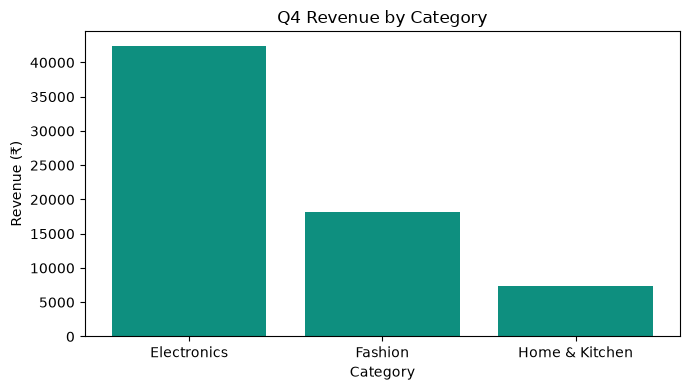

In [23]:
# Visualize the result
plt.figure(figsize=(7, 4))
plt.bar(revenue_by_category["category"], revenue_by_category["revenue"], color="#0E8F7F")
plt.title("Q4 Revenue by Category")
plt.ylabel("Revenue (₹)")
plt.xlabel("Category")
plt.tight_layout()
plt.show()


## HAVING vs WHERE

`WHERE` filters rows *before* grouping. `HAVING` filters groups *after* aggregation.

In [24]:
query = """
SELECT category, SUM(amount) AS total_revenue
FROM sales
GROUP BY category
HAVING SUM(amount) > 100000
ORDER BY total_revenue DESC;
"""
pd.read_sql_query(query, conn)


,category,total_revenue
0,Electronics,166513
1,Home & Kitchen,127374
2,Fashion,121594


## ORDER BY & LIMIT

Sort results and keep only the top rows.

In [25]:
query = """
SELECT c.name, s.amount, s.category, s.sale_date
FROM sales s
JOIN customers c ON c.customer_id = s.customer_id
ORDER BY s.amount DESC
LIMIT 5;
"""
pd.read_sql_query(query, conn)


,name,amount,category,sale_date
0,Jatin Malhotra,14847,Fashion,2026-12-22
1,Gauri Nair,14386,Home & Kitchen,2026-10-30
2,Esha Menon,14315,Electronics,2026-04-20
3,Lokesh Verma,14079,Home & Kitchen,2026-04-04
4,Lokesh Verma,13891,Electronics,2026-12-01


## Subqueries

Find every customer who has placed at least one order over ₹10,000 — using a query nested inside another.

In [26]:
query = """
SELECT *
FROM customers
WHERE customer_id IN (
    SELECT customer_id
    FROM sales
    WHERE amount > 10000
);
"""
pd.read_sql_query(query, conn)


,customer_id,name,city
0,3,Chetan Iyer,Pune
1,5,Esha Menon,Delhi
2,7,Gauri Nair,Mumbai
3,9,Ishita Sharma,Bengaluru
4,10,Jatin Malhotra,Mumbai
5,12,Lokesh Verma,Hyderabad


## SQL Practice Challenge — Answer

**Challenge:** write a query to find the top 3 customers by total amount spent, across all their orders.

In [27]:
query = """
SELECT c.name, SUM(s.amount) AS total_spent
FROM customers c
JOIN sales s ON c.customer_id = s.customer_id
GROUP BY c.customer_id, c.name
ORDER BY total_spent DESC
LIMIT 3;
"""
pd.read_sql_query(query, conn)


,name,total_spent
0,Jatin Malhotra,76200
1,Gauri Nair,58599
2,Ishita Sharma,48677


---
# Recap

- **Demo 1 (ETL):** turned a messy raw CSV into clean, analysis-ready data — Extract → Transform → Load
- **Demo 2 (Data Cleaning Pipeline):** built a repeatable Profile → Clean → Validate → Log pipeline on a customer dataset
- **Demo 3 (Text Preprocessing):** ran raw feedback text through tokenization, normalization, stopword removal, and stemming vs lemmatization
- **Demo 4 (SQL Basics):** ran every core SQL concept from the session against a real SQLite database — SELECT, WHERE, JOIN, GROUP BY, HAVING, ORDER BY/LIMIT, subqueries

All four demos are independent and can be re-run in any order. Files produced by this notebook:
- `raw_orders.csv`, `clean_orders.csv` (Demo 1)
- `customers_raw.csv`, `customers_clean.csv`, `cleaning_change_log.csv` (Demo 2)
- `training.db` (SQLite database used in Demos 1 & 4)


In [ ]:
conn.close()
print("Database connection closed. All demos complete.")

Database connection closed. All demos complete.


---